# 03: Baseline, Logistic Regression

**Author:** Karan Homayounfar (25065219), UWE Bristol  

Logistic Regression serves as the baseline model. It is fast, interpretable, and produces well-calibrated probabilities.  
Ng and Jordan (2001) demonstrate that discriminative classifiers such as Logistic Regression reach their asymptotic error faster than generative models (Naive Bayes) with sufficient data, justifying LR over NB as a baseline here.

**Evaluation methodology:** Nested cross-validation (5-fold outer, 3-fold inner) on the training set, followed by a single final evaluation on the held-out temporal test set (2025-2026).

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, average_precision_score, precision_recall_curve
)

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR    = '../data/processed'
FIGURES_DIR = '../report/figures'

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load preprocessed arrays

In [2]:
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

with open(f'{DATA_DIR}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f'X_train: {X_train.shape}, y_train positive: {y_train.mean():.3f}')
print(f'X_test:  {X_test.shape},  y_test positive:  {y_test.mean():.3f}')

X_train: (200000, 51), y_train positive: 0.217
X_test:  (50000, 51),  y_test positive:  0.108


## 2. Nested cross-validation

The outer loop (5 folds) estimates generalisation error. The inner loop (3 folds) tunes the regularisation parameter C.  
Using nested CV prevents optimistic bias that arises when the same data is used to both tune hyperparameters and estimate performance (Varma and Simon, 2006).

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

base_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

lr_inner = GridSearchCV(
    base_lr,
    param_grid,
    cv=inner_cv,
    scoring='f1_macro',
    n_jobs=-1
)

# Outer loop: collect F1-macro and ROC-AUC scores
outer_f1  = []
outer_auc = []
best_Cs   = []

print('Running nested cross-validation (5 outer folds x 3 inner folds x 5 C values)...')
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    lr_inner.fit(X_tr, y_tr)
    best_Cs.append(lr_inner.best_params_['C'])

    y_pred = lr_inner.predict(X_val)
    y_prob = lr_inner.predict_proba(X_val)[:, 1]

    f1  = f1_score(y_val, y_pred, average='macro')
    auc = roc_auc_score(y_val, y_prob)
    outer_f1.append(f1)
    outer_auc.append(auc)
    print(f'  Fold {fold}: F1-macro={f1:.4f}, ROC-AUC={auc:.4f}, best C={lr_inner.best_params_["C"]}')

print(f'\nNested CV F1-macro:  {np.mean(outer_f1):.4f} +/- {np.std(outer_f1):.4f}')
print(f'Nested CV ROC-AUC:  {np.mean(outer_auc):.4f} +/- {np.std(outer_auc):.4f}')
print(f'Most selected C:    {max(set(best_Cs), key=best_Cs.count)}')

Running nested cross-validation (5 outer folds x 3 inner folds x 5 C values)...
  Fold 1: F1-macro=0.8884, ROC-AUC=0.9779, best C=10
  Fold 2: F1-macro=0.8897, ROC-AUC=0.9781, best C=100
  Fold 3: F1-macro=0.8900, ROC-AUC=0.9772, best C=10
  Fold 4: F1-macro=0.8902, ROC-AUC=0.9772, best C=10
  Fold 5: F1-macro=0.8914, ROC-AUC=0.9778, best C=100

Nested CV F1-macro:  0.8899 +/- 0.0010
Nested CV ROC-AUC:  0.9776 +/- 0.0004
Most selected C:    10


## 3. Final model on full training data

In [4]:
from collections import Counter
best_C = max(set(best_Cs), key=best_Cs.count)

lr_final = LogisticRegression(
    C=best_C,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_final.fit(X_train, y_train)

y_pred_test = lr_final.predict(X_test)
y_prob_test = lr_final.predict_proba(X_test)[:, 1]

lr_test_f1  = f1_score(y_test, y_pred_test, average='macro')
lr_test_auc = roc_auc_score(y_test, y_prob_test)
lr_test_pr  = average_precision_score(y_test, y_prob_test)

print(f'Test set F1-macro:  {lr_test_f1:.4f}')
print(f'Test set ROC-AUC:   {lr_test_auc:.4f}')
print(f'Test set PR-AUC:    {lr_test_pr:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Low potential', 'High potential']))

Test set F1-macro:  0.7666
Test set ROC-AUC:   0.9635
Test set PR-AUC:    0.7729

                precision    recall  f1-score   support

 Low potential       0.99      0.86      0.92     44612
High potential       0.45      0.95      0.61      5388

      accuracy                           0.87     50000
     macro avg       0.72      0.90      0.77     50000
  weighted avg       0.93      0.87      0.89     50000



## 4. Confusion matrix

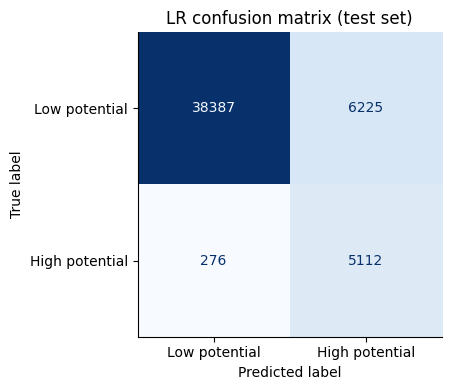

In [5]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Low potential', 'High potential']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('LR confusion matrix (test set)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/lr_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. ROC and Precision-Recall curves

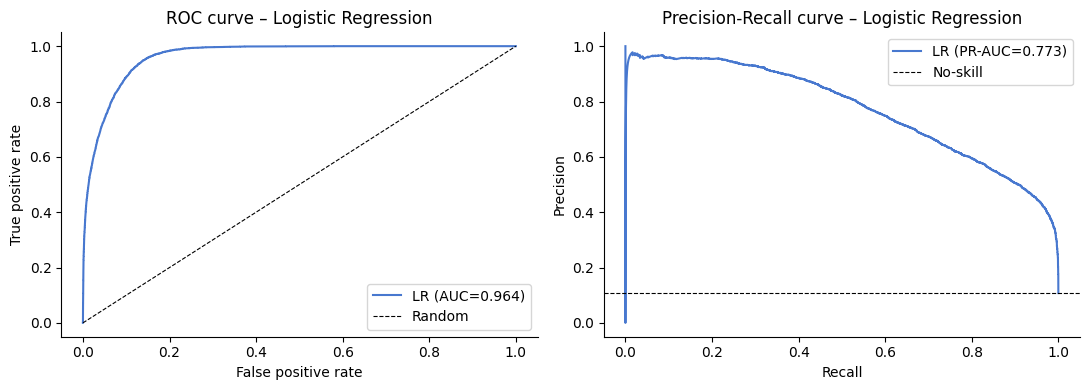

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(fpr, tpr, color='steelblue', label=f'LR (AUC={lr_test_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve – Logistic Regression')
axes[0].legend()

axes[1].plot(rec, prec, color='steelblue', label=f'LR (PR-AUC={lr_test_pr:.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=0.8, label='No-skill')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve – Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/lr_roc_pr.png', bbox_inches='tight')
plt.show()

## 6. Feature coefficients (top 20)

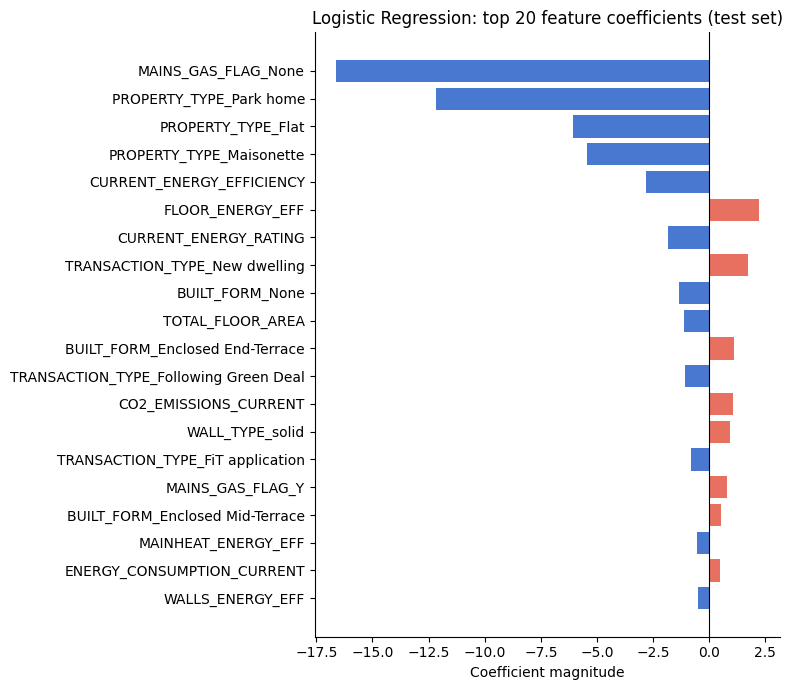

In [7]:
coef = lr_final.coef_[0]
top_idx = np.argsort(np.abs(coef))[::-1][:20]
top_names  = [feature_names[i] for i in top_idx]
top_values = coef[top_idx]

colors = ['coral' if v > 0 else 'steelblue' for v in top_values[::-1]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_names[::-1], top_values[::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient magnitude')
ax.set_title('Logistic Regression: top 20 feature coefficients (test set)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/lr_coefficients.png', bbox_inches='tight')
plt.show()

## 7. Save predictions and model metrics

In [8]:
import pickle

np.save(f'{DATA_DIR}/lr_test_probs.npy', y_prob_test)
np.save(f'{DATA_DIR}/lr_test_preds.npy', y_pred_test)

with open(f'{DATA_DIR}/lr_final_model.pkl', 'wb') as f:
    pickle.dump(lr_final, f)

lr_metrics = {
    'model': 'Logistic Regression',
    'best_C': best_C,
    'cv_f1_macro_mean': np.mean(outer_f1),
    'cv_f1_macro_std':  np.std(outer_f1),
    'cv_roc_auc_mean':  np.mean(outer_auc),
    'cv_roc_auc_std':   np.std(outer_auc),
    'test_f1_macro': lr_test_f1,
    'test_roc_auc':  lr_test_auc,
    'test_pr_auc':   lr_test_pr,
}

with open(f'{DATA_DIR}/lr_metrics.pkl', 'wb') as f:
    pickle.dump(lr_metrics, f)

print('Saved: lr_test_probs.npy, lr_test_preds.npy, lr_final_model.pkl, lr_metrics.pkl')
print('\n=== LR BASELINE SUMMARY ===')
for k, v in lr_metrics.items():
    print(f'  {k}: {v}')

Saved: lr_test_probs.npy, lr_test_preds.npy, lr_final_model.pkl, lr_metrics.pkl

=== LR BASELINE SUMMARY ===
  model: Logistic Regression
  best_C: 10
  cv_f1_macro_mean: 0.889937751368679
  cv_f1_macro_std: 0.0009642101006243498
  cv_roc_auc_mean: 0.9776408391409074
  cv_roc_auc_std: 0.00038899574145140006
  test_f1_macro: 0.7666169008889182
  test_roc_auc: 0.963524829044835
  test_pr_auc: 0.7728919458566678


## Interpretation

Logistic Regression establishes the baseline performance. Key observations:
- `class_weight='balanced'` is essential given class imbalance; without it, the model trivially predicts the majority class.
- The nested CV F1-macro score on training data should be compared against the test set score. A large gap indicates overfitting or temporal distribution shift.
- Coefficient interpretation: positive coefficients increase probability of high retrofit potential; large negative coefficients (e.g., high current efficiency) reduce it, which is intuitive.

**Next:** `04_Random_Forest.ipynb`